# 04 - Machine Learning: Predicting Monthly Receipts

[Back to the statistics notebook](03_statistics.ipynb)

This notebook builds a model to predict total monthly HMRC receipts, answering our last business question: can we predict future monthly receipts?

## Part 1: Machine learning in plain words
- **Target:** the thing we want to predict. Here it is total monthly receipts.
- **Features:** the clues the model uses. Here they are how far along in time we are (the trend) and which month of the year it is.
- **Training set:** the older months the model learns from.
- **Test set:** the most recent 12 months, kept hidden while the model learns. Predicting them tells us how well the model works on data it has never seen.
- **Why we split by time, not randomly:** we want to predict the future from the past. A random split would let the model peek at months that come after the ones it is predicting, which would be cheating.

**Our model:** **_linear regression_**. It draws a trend line through the data, then adds an adjustment for each calendar month, so January gets a boost and May gets a reduction. This matches what the EDA and statistics found: a steady upward trend and a strong yearly pattern.

## Setup: reusable functions and loading the data
We define the functions used in this notebook (loading the data, building features, splitting by time and training the model), then load the cleaned data and pick out total monthly receipts.

In [8]:
# Cell 1
# Bring in pandas for tables and numpy for numbers
import pandas as pd
import numpy as np

# Bring in the linear regression model from scikit-learn
from sklearn.linear_model import LinearRegression

# Bring in scikit-learn's tools for measuring prediction errors
from sklearn.metrics import mean_absolute_error, r2_score


def load_clean_data(file_path="../data/processed/hmrc_clean.csv"):
    """Load the cleaned HMRC data with Month as the row label."""
    # Read the file, turning Month back into real dates
    data = pd.read_csv(file_path, parse_dates=["Month"])

    # Use Month as the row label and hand the table back
    return data.set_index("Month")


def make_features(series):
    """Build the clues the model learns from: a time counter and the month of the year."""
    # Start an empty table with the same dates as our data
    features = pd.DataFrame(index=series.index)

    # A simple counter (0, 1, 2, ...) that lets the model follow the upward trend
    features["Time"] = np.arange(len(series))

    # Turn the month number into one 0/1 column per month
    # drop_first=True leaves out January, so January becomes the baseline the others are compared with
    months = pd.get_dummies(series.index.month, prefix="Month", drop_first=True).astype(int)

    # Give these columns the same dates as the rest of the table, then join them together
    months.index = series.index
    return features.join(months)


def split_by_time(features, target, test_months=12):
    """Keep the last few months for testing and use everything before them for training."""
    # Everything except the last test_months goes to training
    X_train = features.iloc[:-test_months]
    y_train = target.iloc[:-test_months]

    # The last test_months are set aside for testing
    X_test = features.iloc[-test_months:]
    y_test = target.iloc[-test_months:]

    return X_train, X_test, y_train, y_test


def train_model(X_train, y_train):
    """Train a linear regression model and hand it back."""
    # Create an empty model
    model = LinearRegression()

    # Let it learn the link between the clues (X) and the receipts (y)
    model.fit(X_train, y_train)
    return model

def evaluate_predictions(actual, predicted):
    """Measure how far the predictions are from the actual values."""
    # The average miss in £ million, ignoring whether it was too high or too low
    mae = mean_absolute_error(actual, predicted)

    # The average miss as a percentage of the actual value
    mape = (abs(predicted - actual) / actual).mean() * 100

    # How much of the ups and downs the predictions capture (1.0 would be perfect)
    r2 = r2_score(actual, predicted)

    # Hand back all three scores
    return pd.Series({"Average miss (£m)": mae,
                      "Average miss (%)": mape,
                      "R-squared": r2})


def same_month_last_year(series, test_months=12):
    """The simple guess: predict each month with the value from the same month a year earlier."""
    # shift(12) slides every value forward 12 months, so each month lines up with last year's
    return series.shift(12).iloc[-test_months:]

# Use our function to load the data
df = load_clean_data()

# Pick out the thing we want to predict
total = df["Total HMRC Receipts"]

# Check the size, which should be (113, 44)
print(df.shape)

(113, 44)


**Cell 1**

**Action:** Defined four reusable functions (`load_clean_data`, `make_features`, `split_by_time` and `train_model`), then loaded the cleaned data and picked out total monthly receipts as our target.

**Result:** 113 rows and 44 columns, with `Month` as the row label.

## Part 2: Building the model

### Step 1: Create the features
The model needs numbers it can learn from. I give it a time counter, so it can follow the trend, and a set of month columns, so it can learn each month's usual effect.

In [9]:
# Cell 2
# Build the features using our function
X = make_features(total)

# Check the size: 113 rows, with 1 time column and 11 month columns
print(X.shape)

# Show the first three rows to see what the model will learn from
X.head(3)

(113, 12)


,Time,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
Month,,,,,,,,,,,,
2017-04-01,0,0,0,1,0,0,0,0,0,0,0,0
2017-05-01,1,0,0,0,1,0,0,0,0,0,0,0
2017-06-01,2,0,0,0,0,1,0,0,0,0,0,0


**Cell 2**

**Action:** Built the feature table, with a time counter and one 0/1 column for each month except January.

**Result:** 113 rows and 12 columns. The first row (April 2017) has Time 0 and a 1 in the Month_4 column.

**Note:** January has no column because it is the baseline. Every other month's column tells the model how much that month differs from January.

Uses function: `make_features` (Cell 1)

### Step 2: Split the data by time
We train on the older months and keep the most recent 12 hidden for testing. This copies real life, where we predict the future from the past.

In [10]:
# Cell 3
# Split into training and test sets using our function
X_train, X_test, y_train, y_test = split_by_time(X, total)

# Show how many months are in each set
print("Training months:", len(X_train))
print("Test months:", len(X_test))

# Show the date range of each set
print("Training period:", X_train.index[0].strftime("%b %Y"), "to", X_train.index[-1].strftime("%b %Y"))
print("Test period:", X_test.index[0].strftime("%b %Y"), "to", X_test.index[-1].strftime("%b %Y"))

Training months: 101
Test months: 12
Training period: Apr 2017 to Aug 2025
Test period: Sep 2025 to Aug 2026


**Cell 3**

**Action:** Split the data by time, keeping the last 12 months for testing.

**Result:** 101 training months (April 2017 to August 2025) and 12 test months (September 2025 to August 2026).

**Note:** The test period includes January 2026, the biggest month in the whole dataset, so it is a demanding test. The latest months are also provisional and may be revised.

Uses function: `split_by_time` (Cell 1)

### Step 3: Train the model
The model looks at the training months and works out the best trend line, plus the adjustment for each calendar month.

In [11]:
# Cell 4
# Train the model on the training months using our function
model = train_model(X_train, y_train)

# The Time number shows how much the trend rises each month, in £ million
print(f"Trend: receipts rise by about £{model.coef_[0]:,.0f}m per month")

# The month numbers show how each month differs from January, after allowing for the trend
month_effects = pd.Series(model.coef_[1:], index=X_train.columns[1:]).round(0)
print(month_effects)

Trend: receipts rise by about £294m per month
Month_2    -32691.0
Month_3    -36595.0
Month_4    -27835.0
Month_5    -42147.0
Month_6    -40821.0
Month_7    -19678.0
Month_8    -38264.0
Month_9    -39519.0
Month_10   -31336.0
Month_11   -38233.0
Month_12   -36183.0
dtype: float64


**Cell 4**

**Action:** Trained the linear regression model and looked at what it learned.

**Result:** The model found an upward trend of about £294m more receipts each month, which is roughly £3.5bn a year. Every other month is below January. May is the weakest (about £42bn below January) and July is the closest to it (about £20bn below).

**Note:** These numbers fit what we found in the EDA, where January was the highest month and May the lowest.

Uses function: `train_model` (Cell 1)

### Step 4: Predict the test months
Now we ask the model to predict the 12 months it has never seen, and put its predictions next to what really happened.

In [12]:
# Cell 5
# Ask the model to predict receipts for the test months
predictions = pd.Series(model.predict(X_test), index=X_test.index)

# Put the actual and predicted receipts side by side
comparison = pd.DataFrame({"Actual": y_test, "Predicted": predictions})

# Work out the gap: predicted minus actual (a negative number means the model predicted too low)
comparison["Gap"] = comparison["Predicted"] - comparison["Actual"]

# Show the comparison in whole £ million
comparison.round(0)

,Actual,Predicted,Gap
Month,,,
2025-09-01,71201.0,66817.0,-4384.0
2025-10-01,75323.0,75294.0,-29.0
2025-11-01,64944.0,68691.0,3747.0
2025-12-01,79235.0,71036.0,-8199.0
2026-01-01,126444.0,107513.0,-18931.0
2026-02-01,75743.0,75116.0,-627.0
2026-03-01,78194.0,71506.0,-6688.0
2026-04-01,85214.0,80560.0,-4654.0
2026-05-01,65414.0,66543.0,1129.0


**Cell 5**

**Action:** Used the trained model to predict total receipts for the 12 test months and compared them with the actual figures.

**Result:** The model follows the yearly shape well, with January and July as the high months. The biggest miss is January 2026, where it predicted about £107.5bn against an actual £126.4bn. In 9 of the 12 months it predicted too low.

**Note:** The model probably under-predicts because receipts grew faster recently than the long-run trend it learned. 

## Part 3: Why linear regression?

### The reasons, backed by our own findings
- **There is a steady upward trend.** Total receipts grew from about £593bn in 2017/18 to about £938bn in 2025/26 (EDA, Cell 10). A trend line is the natural way to capture that.
- **There is a strong, repeating yearly pattern.** January is about 54% above a typical month and May about 15% below (EDA, Cell 7). The statistics notebook confirmed the January effect is significant and not just a trend effect, so month of the year is a proven clue.
- **The dataset is small.** With only 113 months (101 for training), a simple model is safer than a complex one that could memorise the past.
- **It can be explained.** The model gives us a trend of about £294m more per month and an adjustment for each calendar month. A policy or finance team can understand and challenge those numbers.
- **It can keep following the trend.** A linear model can predict beyond the highest values it has seen. That matters here, because receipts keep rising.

### Alternatives considered
- **Random forest:** handles uneven patterns, but it cannot predict above the highest value it has seen, so it tends to flatten when receipts keep rising. With 101 training months it could also memorise the past. We will test it as a second model to compare, instead of just assuming.
- **Time-series models such as SARIMA:** designed for this kind of data, but they are harder to explain, need extra libraries beyond our toolset (pandas, SciPy and scikit-learn), and add complexity we don't need for a first model.
- **Neural networks:** need far more data than 113 months, so they would almost certainly overfit.

### Assumptions and weaknesses
- The trend is assumed to be a straight line. Our results suggest receipts grew faster recently, and the model predicted too low in 9 of the 12 test months.
- The seasonal pattern is assumed to be the same size every year, but January 2026 was far higher than the model expected.
- The Covid dip in 2020/21 sits inside the training data and does not fit a straight trend neatly.
- The latest months are provisional and may be revised.

### Conclusion
Linear regression with a trend and month-of-year features is a sensible first model for this data: it matches the patterns we found, suits a small dataset, and is easy to explain. Its main weakness is that it under-predicts when growth speeds up, which we measure properly in the next section.

## Part 4: Evaluating the model
A model is only useful if it beats a simple guess. We measure the model's errors on the 12 test months, then compare them with a baseline: predicting each month with the value from the same month a year earlier.

### Step 1: Measure the model's errors
We score the model's predictions for the 12 test months, in £ million and as a percentage of the actual value.

In [13]:
# Cell 6
# Score the model's predictions for the test months using our function
model_scores = evaluate_predictions(y_test, predictions)

# Show the scores
print(model_scores.round(2))

Average miss (£m)    5425.10
Average miss (%)        6.16
R-squared               0.80
dtype: float64


**Cell 6**

**Action:** Measured how far the model's predictions were from the actual receipts in the 12 test months.

**Result:** On average the model missed by about £5.4bn a month, which is about 6.2% of the actual value. Its R-squared is 0.80, meaning it captures about 80% of the ups and downs in monthly receipts.

Uses function: `evaluate_predictions` (Cell 1)

### Step 2: Compare with a simple baseline
The obvious guess is "this month will look like the same month last year". If ourthis model can't beat that, it isn't adding value. We score it in exactly the same way, so the comparison is fair.

In [14]:
# Cell 7
# Build the simple guess: each month predicted by the same month a year earlier
baseline = same_month_last_year(total)

# Score the baseline with the same function
baseline_scores = evaluate_predictions(y_test, baseline)

# Show the scores
print(baseline_scores.round(2))

Average miss (£m)    6642.67
Average miss (%)        8.13
R-squared               0.80
dtype: float64


**Cell 7**

**Action:** Built the baseline (same month last year) and scored it in the same way as the model.

**Result:** The baseline missed by about £6.6bn on average, about 8.1%. Its R-squared is also about 0.80.

**Note:** Both capture roughly the same share of the ups and downs, because both know about the yearly pattern. The difference is in how far off they are.

Uses functions: `same_month_last_year` and `evaluate_predictions` (Cell 1)

### Step 4: See it on a chart
A chart shows where the model follows the real pattern and where it falls behind.

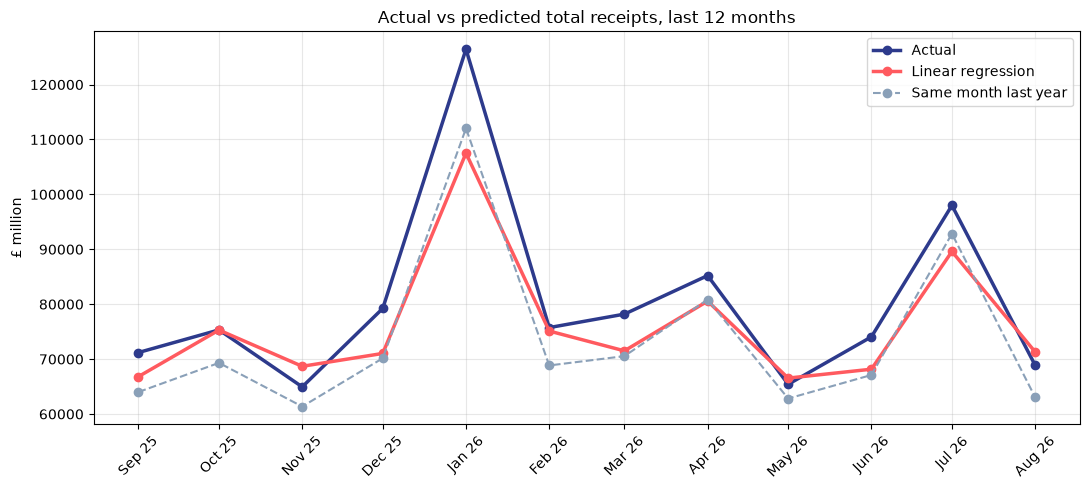

In [15]:
# Cell 9
# Bring in matplotlib for drawing the chart
import matplotlib.pyplot as plt

# Make the chart wide enough to read
plt.figure(figsize=(11, 5))

# Draw the actual receipts as a thick dark line
plt.plot(y_test.index, y_test, marker="o", color="#2d3a8c", linewidth=2.5, label="Actual")

# Draw the model's predictions in red
plt.plot(predictions.index, predictions, marker="o", color="#ff5a5f", linewidth=2.5, label="Linear regression")

# Draw the baseline as a dashed grey line
plt.plot(baseline.index, baseline, marker="o", color="#8aa0b8", linestyle="--", label="Same month last year")

# Label every month on the horizontal axis, tilted so the names fit
plt.xticks(y_test.index, y_test.index.strftime("%b %y"), rotation=45)

# Add a title, an axis label, a legend and a light grid
plt.title("Actual vs predicted total receipts, last 12 months")
plt.ylabel("£ million")
plt.legend()
plt.grid(alpha=0.3)

# Tidy the spacing and show the chart
plt.tight_layout()
plt.show()

**Cell 9**

**Action:** Plotted the actual receipts, the model's predictions and the baseline for the 12 test months.

**Result:** Both guesses follow the yearly shape closely, with peaks in January and July. The biggest miss for both is January 2026, where actual receipts jumped far above either prediction. The model sits closer to the actual line than the baseline in most other months.

## Evaluation summary

### What the model gets right
- It captures the yearly pattern, with January and July as the high months and May as the low month.
- It beats the simple baseline: an average miss of about £5.4bn (6.2%) against about £6.6bn (8.1%), and it was closer in 8 of 12 months.
- Leaving out January 2026, the model's average miss falls to about £4.2bn, against about £5.9bn for the baseline.

### What it gets wrong
- It tends to predict too low, by about £4.2bn on average, and it was too low in 9 of the 12 months. Receipts grew faster recently than the long-run trend line the model learned.
- It struggles most with January. In January 2026 it missed by about £18.9bn, or 15%.
- It treats the seasonal pattern as the same size every year, which is not quite true.

### Limitations
- The test covers only 12 months, so the scores are a rough guide.
- The latest months are provisional and may be revised.
- The Covid dip in the training data does not fit a straight-line trend.

### What I would try next
- A second model, a random forest, to see whether it captures the uneven pattern better (user story 22).
- Extra clues, such as the value from the same month last year.
- Training only on the period after Covid, so the trend reflects recent growth.

### Business use
The model gives a useful rough planning figure, within about 6% on average, but it should not be trusted for January without a safety margin.